# 05 — L-BFGS Grid Search

Grid search for the L-BFGS algorithm (A1), using the same configuration parameters and plotting style used in `02_lbfgs_experiments.ipynb`.

In [3]:
import sys
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set a font that supports Unicode mathematical symbols
plt.rcParams['font.family'] = 'DejaVu Sans'

from lib.lbfgs import lbfgs_optimize, theoretical_cost
from lib.utils import solve_exact, compute_condition_number, load_ml_cup

## Data Setup

In [4]:
# Load the real dataset
file_path = Path("dataset") / "ML-CUP25-TR.csv"

X, y, m, n = load_ml_cup(file_path, seed=42)
base_lambda = 0.5

# Exact solution (baseline)
w_star, f_star, star_time = solve_exact(X, y, base_lambda)
kappa = compute_condition_number(X, base_lambda)

print(f"ML-CUP dataset loaded: m={m}, n={n}")
print(f"m={m}, n={n}, λ={base_lambda}")
print(f"κ(X̂) = {kappa:.2f}")
print(f"f(w*) = {f_star:.10e}")
print(f"Exact baseline time: {star_time:.5f}s")

ML-CUP dataset loaded: m=500, n=12
m=500, n=12, λ=0.5
κ(X̂) = 151.49
f(w*) = 9.2631982939e-02
Exact baseline time: 0.00482s


## Grid Definition

In [5]:
# Each key is a parameter name, each value is the list of values to test.
# The names follow the report / notebook terminology; they are mapped to
# lbfgs_optimize arguments in run_lbfgs_grid_point.
grid = {
    'lam': [base_lambda, 1e-2],
    'h0_scaling': ['nocedal', 'bb1', 'safeguarded'],
    'm_history': [3, 5, 10, 20, 40],        # memory: previous (s_k, y_k) pairs used to approximate H_k
    'line_search': ['exact', 'wolfe'],
    'wolfe_c1': [1e-4],
    'wolfe_c2': [0.5, 0.9],
    'use_restart': [False, True],
    'restart_xi': [0.20, 0.50],
    'init_strategy': ['zeros', 'random N(0,1)', 'random N(0,100²)', 'near optimum'],
    'tol': [1e-10],
    'tol_type': ['relative'],
    'max_iter': [1000],
}

param_names = list(grid.keys())

In [6]:
def is_effective_combination(params):
    """Remove combinations that differ only in parameters ignored by the optimizer."""
    if params['line_search'] == 'exact':
        if params['wolfe_c2'] != grid['wolfe_c2'][0]:
            return False

    if not params['use_restart']:
        if params['restart_xi'] != grid['restart_xi'][0]:
            return False

    return True


def build_grid_points(grid):
    points = []
    for values in itertools.product(*[grid[name] for name in param_names]):
        params = dict(zip(param_names, values))
        if is_effective_combination(params):
            points.append(params)
    return points


grid_points = build_grid_points(grid)
n_combs = len(grid_points)
raw_combs = int(np.prod([len(grid[name]) for name in param_names]))

print(f"Raw Cartesian combinations: {raw_combs}")
print(f"Effective combinations: {n_combs}")

Raw Cartesian combinations: 1920
Effective combinations: 1080


## Grid Search

In [7]:
baseline_cache = {}

def get_baseline(lam_val):
    """Cache exact solutions because the same λ appears in many grid points."""
    if lam_val not in baseline_cache:
        w_s, f_s, t_s = solve_exact(X, y, lam_val)
        baseline_cache[lam_val] = {
            'w_star': w_s,
            'f_star': f_s,
            'time': t_s,
            'kappa': compute_condition_number(X, lam_val),
        }
    return baseline_cache[lam_val]


def make_initial_point(init_strategy, w_s):
    """Return the requested initial point with deterministic randomness."""
    rng = np.random.default_rng(42)
    if init_strategy == 'zeros':
        return None
    if init_strategy == 'random N(0,1)':
        return rng.standard_normal(m)
    if init_strategy == 'random N(0,100²)':
        return 100.0 * rng.standard_normal(m)
    if init_strategy == 'near optimum':
        return w_s + 0.01 * rng.standard_normal(m)
    raise ValueError(f"Unknown init_strategy={init_strategy}")


def run_lbfgs_grid_point(params):
    """Run one L-BFGS configuration and return the metrics used below."""
    baseline = get_baseline(params['lam'])
    w_s = baseline['w_star']
    f_s = baseline['f_star']
    w0 = make_initial_point(params['init_strategy'], w_s)

    lbfgs_params = {k: v for k, v in params.items() if k not in ['init_strategy']}

    w_opt, hist, elapsed = lbfgs_optimize(
        X, y,
        w_init=w0,
        w_star=w_s, f_star=f_s,
        verbose=False,
        **lbfgs_params)

    return {
        **params,
        'time': elapsed,
        'n_iter': len(hist['f']) - 1,
        'final_f': hist['f'][-1],
        'final_gap': hist['f'][-1] - f_s,
        'final_grad_norm': hist['grad_norm'][-1],
        'n_restarts': len(hist['restarts']),
        'w_error': np.linalg.norm(w_opt - w_s),
        'kappa': baseline['kappa'],
        'history': hist,
    }

In [8]:
rows = []
for i, params in enumerate(grid_points, start=1):
    row = run_lbfgs_grid_point(params)
    rows.append(row)

    # Print
    params_text = ', '.join(f"{name}={value}" for name, value in params.items())
    print(f"[{i}/{n_combs}] {params_text} --> time={row['time']:.6f}s")

grid_results = pd.DataFrame(rows)
grid_results.sort_values(['time', 'final_grad_norm']).reset_index(drop=True).head(10)

[1/1080] lam=0.5, h0_scaling=nocedal, m_history=3, line_search=exact, wolfe_c1=0.0001, wolfe_c2=0.5, use_restart=False, restart_xi=0.2, init_strategy=zeros, tol=1e-10, tol_type=relative, max_iter=1000 --> time=0.016420s
[2/1080] lam=0.5, h0_scaling=nocedal, m_history=3, line_search=exact, wolfe_c1=0.0001, wolfe_c2=0.5, use_restart=False, restart_xi=0.2, init_strategy=random N(0,1), tol=1e-10, tol_type=relative, max_iter=1000 --> time=0.001365s
[3/1080] lam=0.5, h0_scaling=nocedal, m_history=3, line_search=exact, wolfe_c1=0.0001, wolfe_c2=0.5, use_restart=False, restart_xi=0.2, init_strategy=random N(0,100²), tol=1e-10, tol_type=relative, max_iter=1000 --> time=0.001252s
[4/1080] lam=0.5, h0_scaling=nocedal, m_history=3, line_search=exact, wolfe_c1=0.0001, wolfe_c2=0.5, use_restart=False, restart_xi=0.2, init_strategy=near optimum, tol=1e-10, tol_type=relative, max_iter=1000 --> time=0.056485s
[5/1080] lam=0.5, h0_scaling=nocedal, m_history=3, line_search=exact, wolfe_c1=0.0001, wolfe_c

,lam,h0_scaling,m_history,line_search,wolfe_c1,wolfe_c2,use_restart,restart_xi,init_strategy,tol,...,max_iter,time,n_iter,final_f,final_gap,final_grad_norm,n_restarts,w_error,kappa,history
0,0.50,nocedal,20,exact,0.0001,0.5,True,0.5,zeros,1.000000e-10,...,1000,0.000461,12,0.092632,1.387779e-17,4.401185e-09,0,6.829827e-10,151.494691,"{'f': [3.5719586058355284, 2.9046227563256135,..."
1,0.50,nocedal,40,exact,0.0001,0.5,True,0.5,zeros,1.000000e-10,...,1000,0.000464,12,0.092632,1.387779e-17,4.401185e-09,0,6.829827e-10,151.494691,"{'f': [3.5719586058355284, 2.9046227563256135,..."
2,0.50,bb1,10,exact,0.0001,0.5,True,0.5,zeros,1.000000e-10,...,1000,0.000465,12,0.092632,2.775558e-17,4.401185e-09,0,6.829826e-10,151.494691,"{'f': [3.5719586058355284, 2.9046227563256135,..."
3,0.50,nocedal,40,exact,0.0001,0.5,True,0.2,zeros,1.000000e-10,...,1000,0.000466,12,0.092632,1.387779e-17,4.401185e-09,0,6.829827e-10,151.494691,"{'f': [3.5719586058355284, 2.9046227563256135,..."
4,0.01,bb1,20,exact,0.0001,0.5,True,0.5,zeros,1.000000e-10,...,1000,0.000466,12,0.000038,2.934122e-18,6.060046e-09,0,1.569060e-09,7574.569577,"{'f': [3.5719586058355284, 2.9045933418284675,..."
5,0.01,bb1,20,exact,0.0001,0.5,True,0.2,zeros,1.000000e-10,...,1000,0.000468,12,0.000038,2.934122e-18,6.060046e-09,0,1.569060e-09,7574.569577,"{'f': [3.5719586058355284, 2.9045933418284675,..."
6,0.50,bb1,20,exact,0.0001,0.5,True,0.5,zeros,1.000000e-10,...,1000,0.000469,12,0.092632,2.775558e-17,4.401185e-09,0,6.829826e-10,151.494691,"{'f': [3.5719586058355284, 2.9046227563256135,..."
7,0.01,nocedal,20,exact,0.0001,0.5,True,0.5,zeros,1.000000e-10,...,1000,0.000472,12,0.000038,2.940898e-18,6.060045e-09,0,1.569060e-09,7574.569577,"{'f': [3.5719586058355284, 2.9045933418284675,..."
8,0.50,bb1,10,exact,0.0001,0.5,True,0.2,zeros,1.000000e-10,...,1000,0.000472,12,0.092632,2.775558e-17,4.401185e-09,0,6.829826e-10,151.494691,"{'f': [3.5719586058355284, 2.9046227563256135,..."
9,0.01,nocedal,20,exact,0.0001,0.5,True,0.2,zeros,1.000000e-10,...,1000,0.000472,12,0.000038,2.940898e-18,6.060045e-09,0,1.569060e-09,7574.569577,"{'f': [3.5719586058355284, 2.9045933418284675,..."


## Best Configuration

In [9]:
best_row = grid_results.sort_values(['time', 'final_grad_norm']).iloc[0]
best_params = {name: best_row[name] for name in param_names}

print("Best configuration")
for name in param_names:
    print(f"  {name}: {best_params[name]}")
print(f"  time: {best_row['time']:.6f}s")
print(f"  iterations: {int(best_row['n_iter'])}")
print(f"  final ||∇f||: {best_row['final_grad_norm']:.2e}")
print(f"  ||w-w*||: {best_row['w_error']:.2e}")

Best configuration
  lam: 0.5
  h0_scaling: nocedal
  m_history: 20
  line_search: exact
  wolfe_c1: 0.0001
  wolfe_c2: 0.5
  use_restart: True
  restart_xi: 0.5
  init_strategy: zeros
  tol: 1e-10
  tol_type: relative
  max_iter: 1000
  time: 0.000461s
  iterations: 12
  final ||∇f||: 4.40e-09
  ||w-w*||: 6.83e-10


## Helpers for Plot Slices

In [10]:
slice_params = {
    'lam': base_lambda,
    'h0_scaling': 'nocedal',
    'm_history': 10,
    'line_search': 'wolfe',
    'wolfe_c1': 1e-4,
    'wolfe_c2': 0.9,
    'use_restart': True,
    'restart_xi': 0.20,
    'init_strategy': 'zeros',
    'tol': 1e-10,
    'tol_type': 'relative',
    'max_iter': 1000,
}
plot_param_names = [name for name in param_names if len(grid[name]) > 1]


def _matches_fixed(row, fixed, varying):
    """Compare with fixed params, accounting for ignored conditional params."""
    for other_name in param_names:
        if other_name == varying:
            continue
        if row['line_search'] == 'exact' and other_name in ('wolfe_c1', 'wolfe_c2'):
            continue
        if not row['use_restart'] and other_name == 'restart_xi':
            continue
        if row[other_name] != fixed.get(other_name, grid[other_name][0]):
            return False
    return True


def get_slice(param_name, fixed=None):
    """Fix all parameters except param_name and return the matching rows."""
    if fixed is None:
        fixed = slice_params

    slice_df = grid_results[
        grid_results.apply(lambda row: _matches_fixed(row, fixed, param_name), axis=1)
    ].copy()
    order = {value: pos for pos, value in enumerate(grid[param_name])}
    slice_df['plot_order'] = slice_df[param_name].map(order)
    return slice_df.sort_values('plot_order')


def nearest_row(filters):
    """Return one row matching filters; useful for experiment-style plots."""
    mask = np.ones(len(grid_results), dtype=bool)
    for key, value in filters.items():
        mask &= grid_results[key].eq(value)
    matches = grid_results.loc[mask]
    if matches.empty:
        raise ValueError(f"No row found for filters={filters}")
    return matches.sort_values(['time', 'final_grad_norm']).iloc[0]

## One-Parameter Grid Slices

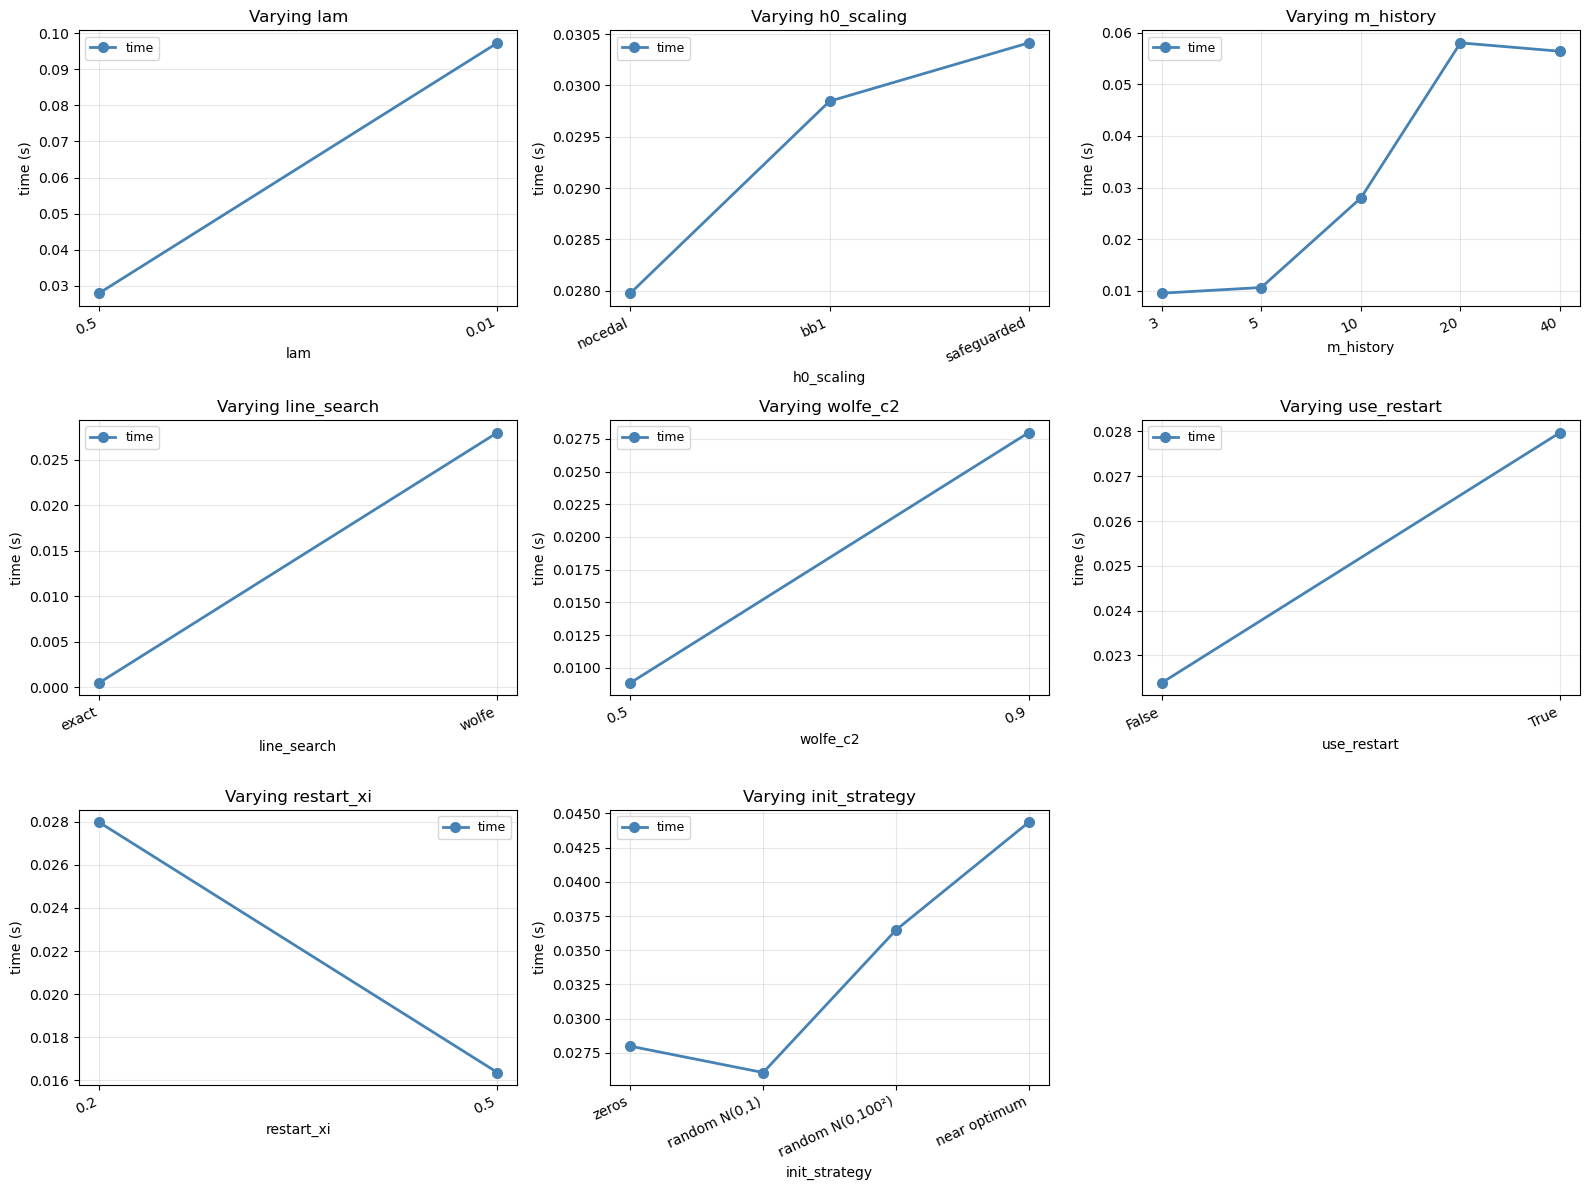

In [11]:
# In each plot all parameters are fixed to the best configuration,
# except the parameter shown on the x-axis.
n_cols = 3
n_rows = int(np.ceil(len(plot_param_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

for ax, param_name in zip(axes, plot_param_names):
    slice_df = get_slice(param_name)
    x = np.arange(len(slice_df))

    ax.plot(x, slice_df['time'], 'o-', lw=2, ms=7,
            color='steelblue', label='time')
    ax.set_xticks(x)
    ax.set_xticklabels(slice_df[param_name].astype(str), rotation=25, ha='right')
    ax.set_xlabel(param_name)
    ax.set_ylabel('time (s)')
    ax.set_title(f"Varying {param_name}")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

for ax in axes[len(plot_param_names):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

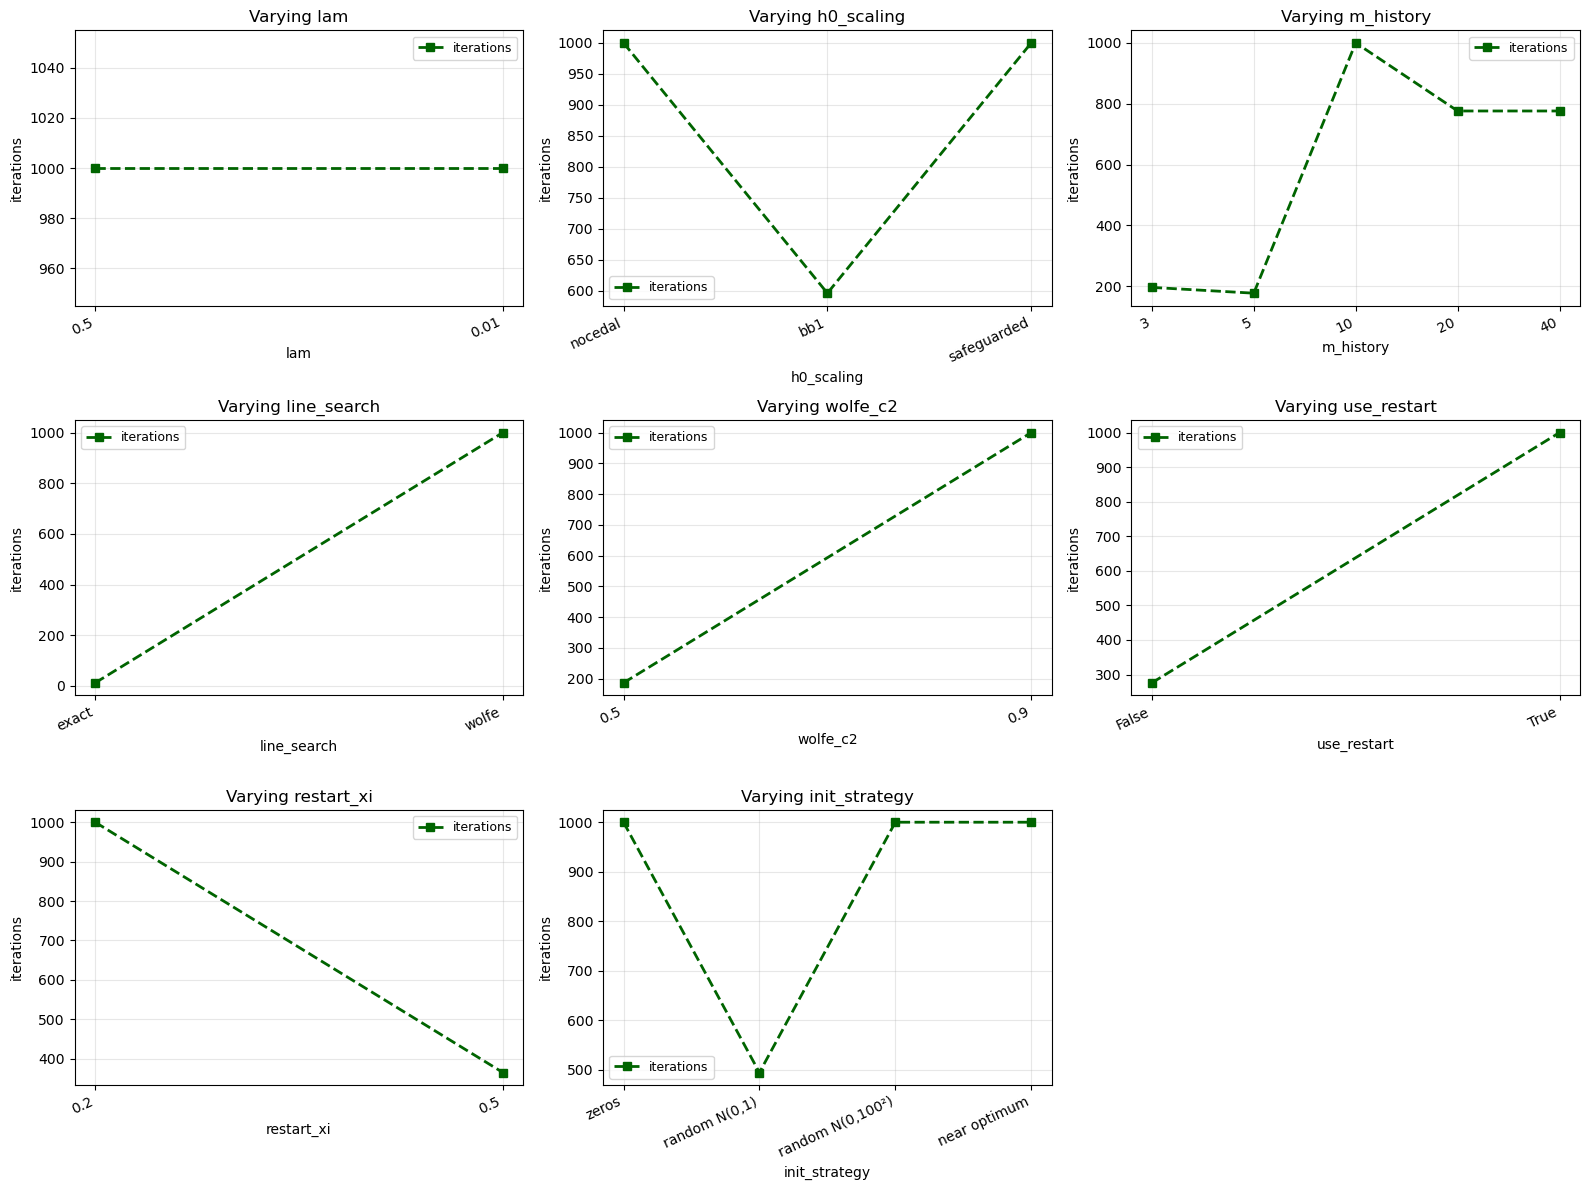

In [12]:
n_cols = 3
n_rows = int(np.ceil(len(plot_param_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.ravel()

for ax, param_name in zip(axes, plot_param_names):
    slice_df = get_slice(param_name)
    x = np.arange(len(slice_df))

    ax.plot(x, slice_df['n_iter'], 's--', lw=2, ms=6,
            color='darkgreen', label='iterations')
    ax.set_xticks(x)
    ax.set_xticklabels(slice_df[param_name].astype(str), rotation=25, ha='right')
    ax.set_xlabel(param_name)
    ax.set_ylabel('iterations')
    ax.set_title(f"Varying {param_name}")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

for ax in axes[len(plot_param_names):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## Experiment Plots from the Grid

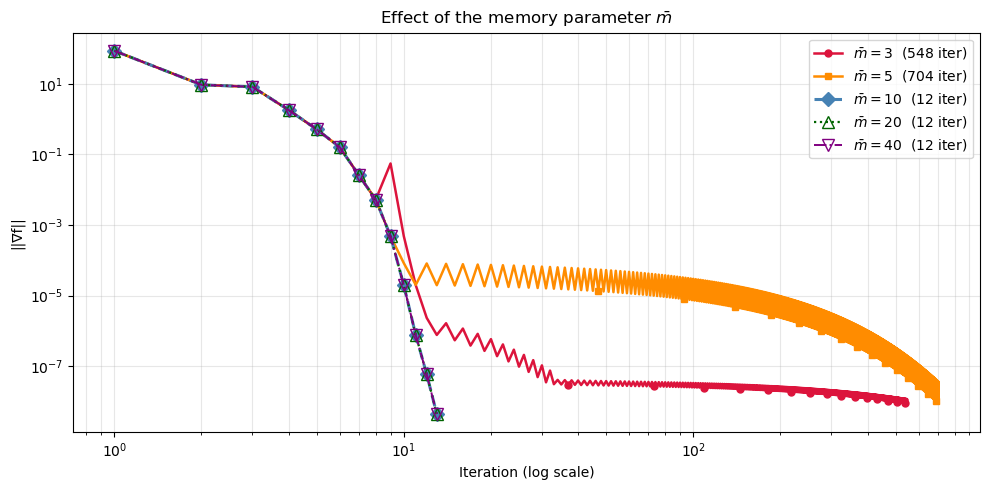

In [13]:
# Memory effect: same log-log structure used in 02_lbfgs_experiments.ipynb.
results_mem = {}
for mh in [3, 5, 10, 20, 40]:
    row = nearest_row({
        'lam': base_lambda,
        'h0_scaling': 'nocedal',
        'm_history': mh,
        'line_search': 'exact',
        'wolfe_c1': 1e-4,
        'wolfe_c2': 0.5,
        'use_restart': False,
        'restart_xi': 0.20,
        'init_strategy': 'zeros',
    })
    results_mem[mh] = row['history']

fig, ax = plt.subplots(figsize=(10, 5))

mh_styles = {
    3:  ('o-',  1.8, 5, False, 'crimson'),
    5:  ('s-',  1.8, 4, False, 'darkorange'),
    10: ('D--', 2.2, 7, False, 'steelblue'),
    20: ('^:',  1.6, 8, True,  'darkgreen'),
    40: ('v-.', 1.4, 9, True,  'purple'),
}

for mh, h in results_mem.items():
    ls, lw, ms, hollow, color = mh_styles[mh]
    n_iter = len(h['grad_norm']) - 1
    label = f'$\\bar{{m}}={mh}$  ({n_iter} iter)'
    kw = dict(lw=lw, ms=ms, color=color, label=label)
    if hollow:
        kw['markerfacecolor'] = 'none'
    iters = np.arange(1, len(h['grad_norm']) + 1)
    ax.loglog(iters, h['grad_norm'], ls, **kw,
              markevery=max(1, (len(h['grad_norm'])-1)//15))

ax.set(xlabel='Iteration (log scale)', ylabel='||∇f||',
       title='Effect of the memory parameter $\\bar{m}$')
ax.legend(fontsize=10); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

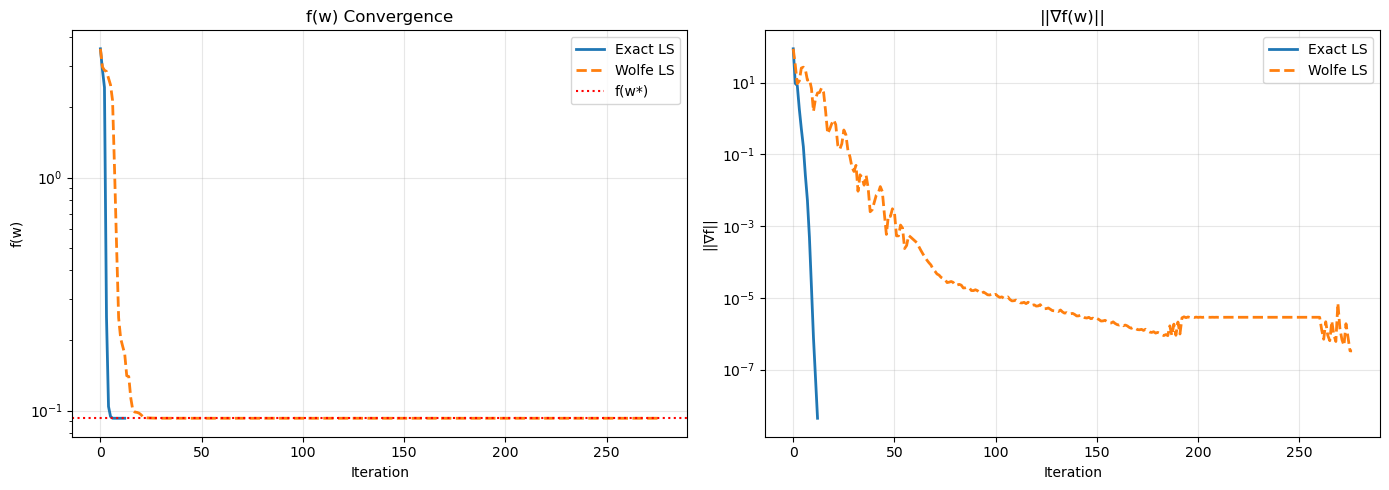

In [14]:
# Exact vs Wolfe line search: same 1x2 convergence structure.
line_rows = {}
for label, ls_name, c2 in [('Exact LS', 'exact', 0.5),
                           ('Wolfe LS', 'wolfe', 0.9)]:
    row = nearest_row({
        'lam': base_lambda,
        'h0_scaling': 'nocedal',
        'm_history': 10,
        'line_search': ls_name,
        'wolfe_c1': 1e-4,
        'wolfe_c2': c2,
        'use_restart': False,
        'restart_xi': 0.20,
        'init_strategy': 'zeros',
    })
    line_rows[label] = row['history']

h_ex = line_rows['Exact LS']
h_wo = line_rows['Wolfe LS']
base = get_baseline(base_lambda)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(h_ex['f'], lw=2, label='Exact LS')
axes[0].semilogy(h_wo['f'], lw=2, ls='--', label='Wolfe LS')
axes[0].axhline(base['f_star'], color='r', ls=':', label='f(w*)')
axes[0].set(xlabel='Iteration', ylabel='f(w)', title='f(w) Convergence')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogy(h_ex['grad_norm'], lw=2, label='Exact LS')
axes[1].semilogy(h_wo['grad_norm'], lw=2, ls='--', label='Wolfe LS')
axes[1].set(xlabel='Iteration', ylabel='||∇f||', title='||∇f(w)||')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

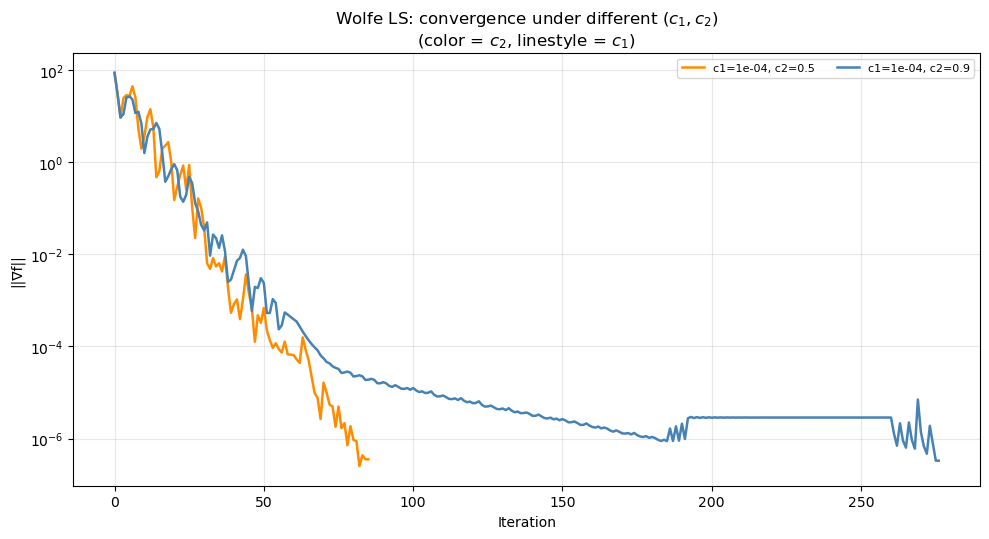

In [15]:
# Wolfe constants: color = c2, linestyle = c1.
results_wolfe = {}
for c1 in grid['wolfe_c1']:
    for c2 in grid['wolfe_c2']:
        row = nearest_row({
            'lam': base_lambda,
            'h0_scaling': 'nocedal',
            'm_history': 10,
            'line_search': 'wolfe',
            'wolfe_c1': c1,
            'wolfe_c2': c2,
            'use_restart': False,
            'restart_xi': 0.20,
            'init_strategy': 'zeros',
        })
        results_wolfe[(c1, c2)] = row['history']

fig, ax = plt.subplots(figsize=(10, 5.5))

c2_colors = {0.5: 'darkorange', 0.9: 'steelblue'}
c1_styles = {1e-4: '-', 1e-3: '--', 1e-2: ':'}

for (c1, c2), h in results_wolfe.items():
    ax.semilogy(h['grad_norm'],
                ls=c1_styles.get(c1, '-'), lw=1.8,
                color=c2_colors[c2],
                label=f'c1={c1:.0e}, c2={c2}')

ax.set(xlabel='Iteration', ylabel='||∇f||',
       title='Wolfe LS: convergence under different $(c_1, c_2)$\n'
             '(color = $c_2$, linestyle = $c_1$)')
ax.legend(fontsize=8, ncol=2, loc='upper right')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

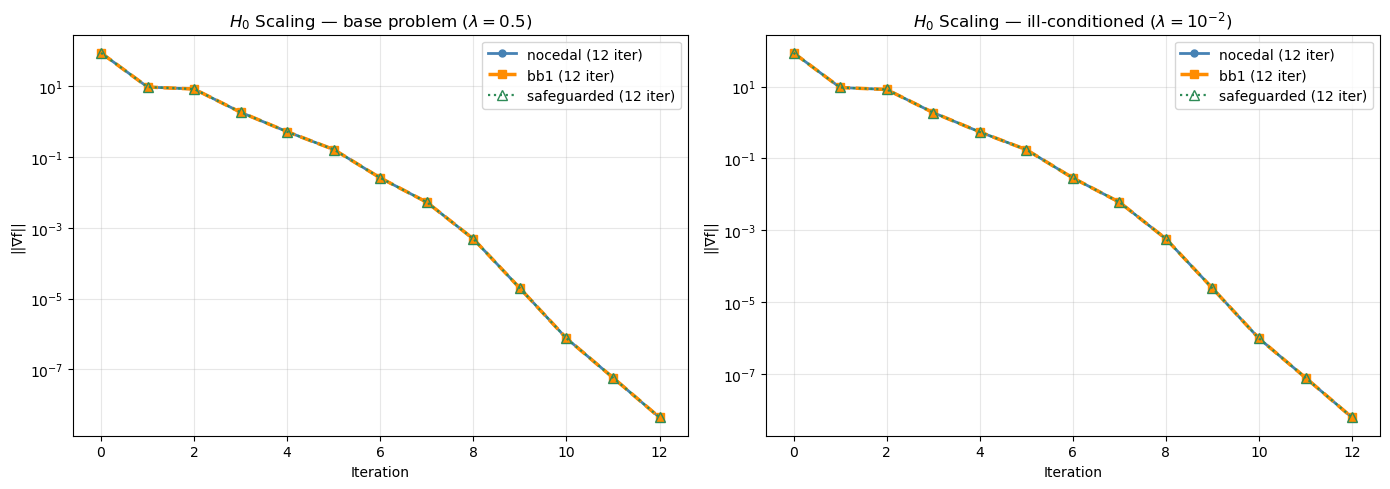

In [16]:
# H0 scaling comparison: same side-by-side structure for two conditioning regimes.
scaling_strategies = ['nocedal', 'bb1', 'safeguarded']
results_scaling = {}

for lam_val in [base_lambda, 1e-2]:
    results_scaling[lam_val] = {}
    for sc in scaling_strategies:
        row = nearest_row({
            'lam': lam_val,
            'h0_scaling': sc,
            'm_history': 10,
            'line_search': 'exact',
            'wolfe_c1': 1e-4,
            'wolfe_c2': 0.5,
            'use_restart': False,
            'restart_xi': 0.20,
            'init_strategy': 'zeros',
        })
        results_scaling[lam_val][sc] = row['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc_styles = {
    'nocedal':     ('-',  2.0, 'o', 5,  False, 'steelblue'),
    'bb1':         ('--', 2.5, 's', 6,  False, 'darkorange'),
    'safeguarded': (':',  1.6, '^', 7,  True,  'seagreen'),
}

for ax, lam_val, title in zip(
        axes,
        [base_lambda, 1e-2],
        ['$H_0$ Scaling — base problem ($\\lambda = 0.5$)',
         '$H_0$ Scaling — ill-conditioned ($\\lambda = 10^{-2}$)']):

    for sc in scaling_strategies:
        h = results_scaling[lam_val][sc]
        ls, lw, mk, ms, hollow, color = sc_styles[sc]
        n_iter = len(h['grad_norm']) - 1
        kw = dict(lw=lw, color=color, marker=mk, markersize=ms,
                  label=f'{sc} ({n_iter} iter)',
                  markevery=max(1, n_iter // 10))
        if hollow:
            kw['markerfacecolor'] = 'none'
        ax.semilogy(h['grad_norm'], ls, **kw)

    ax.set(xlabel='Iteration', ylabel='||∇f||', title=title)
    ax.legend(); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

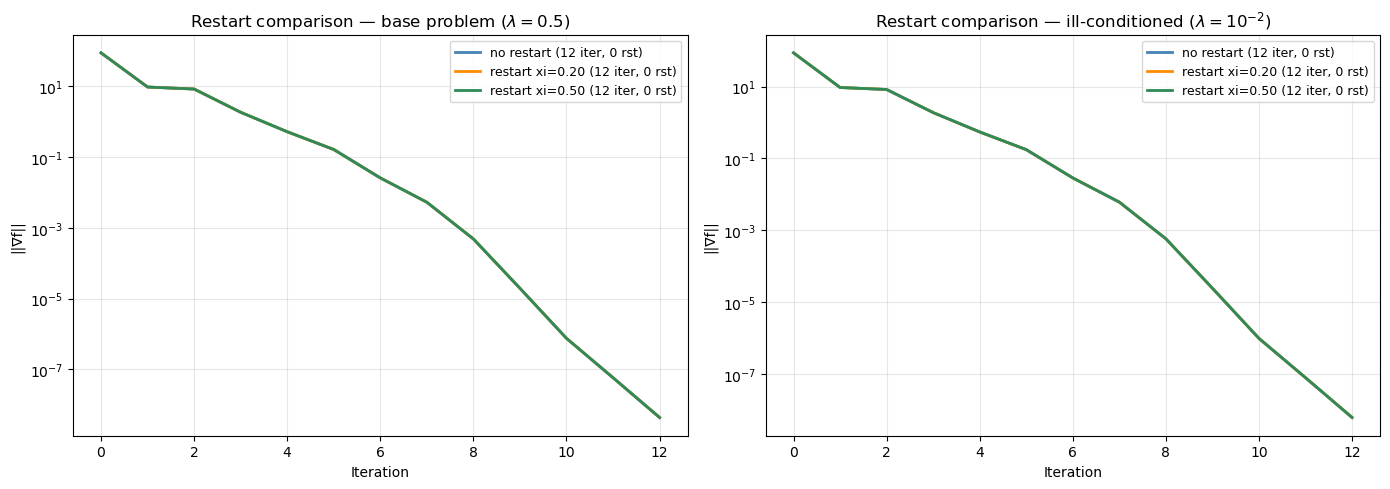

In [17]:
# Restart ON vs OFF: same side-by-side structure.
restart_configs = [('no restart', dict(use_restart=False, restart_xi=grid['restart_xi'][0]))]
restart_configs += [
    (f"restart xi={xi:.2f}", dict(use_restart=True, restart_xi=xi))
    for xi in grid['restart_xi']
]
cfg_colors = {'no restart': 'steelblue'}
restart_colors = ['darkorange', 'seagreen', 'purple', 'crimson']
for (label, _), color in zip(restart_configs[1:], restart_colors):
    cfg_colors[label] = color
results_restart = {}

for lam_val in [base_lambda, 1e-2]:
    results_restart[lam_val] = {}
    for label, kwargs in restart_configs:
        row = nearest_row({
            'lam': lam_val,
            'h0_scaling': 'nocedal',
            'm_history': 10,
            'line_search': 'exact',
            'wolfe_c1': 1e-4,
            'wolfe_c2': 0.5,
            'init_strategy': 'zeros',
            **kwargs,
        })
        results_restart[lam_val][label] = row['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lam_val, title in zip(
        axes,
        [base_lambda, 1e-2],
        ['Restart comparison — base problem ($\\lambda = 0.5$)',
         'Restart comparison — ill-conditioned ($\\lambda = 10^{-2}$)']):

    for label, h in results_restart[lam_val].items():
        n_iter = len(h['grad_norm']) - 1
        nrst = len(h['restarts'])
        ax.semilogy(h['grad_norm'], lw=2, color=cfg_colors[label],
                    label=f'{label} ({n_iter} iter, {nrst} rst)')

    ax.set(xlabel='Iteration', ylabel='||∇f||', title=title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

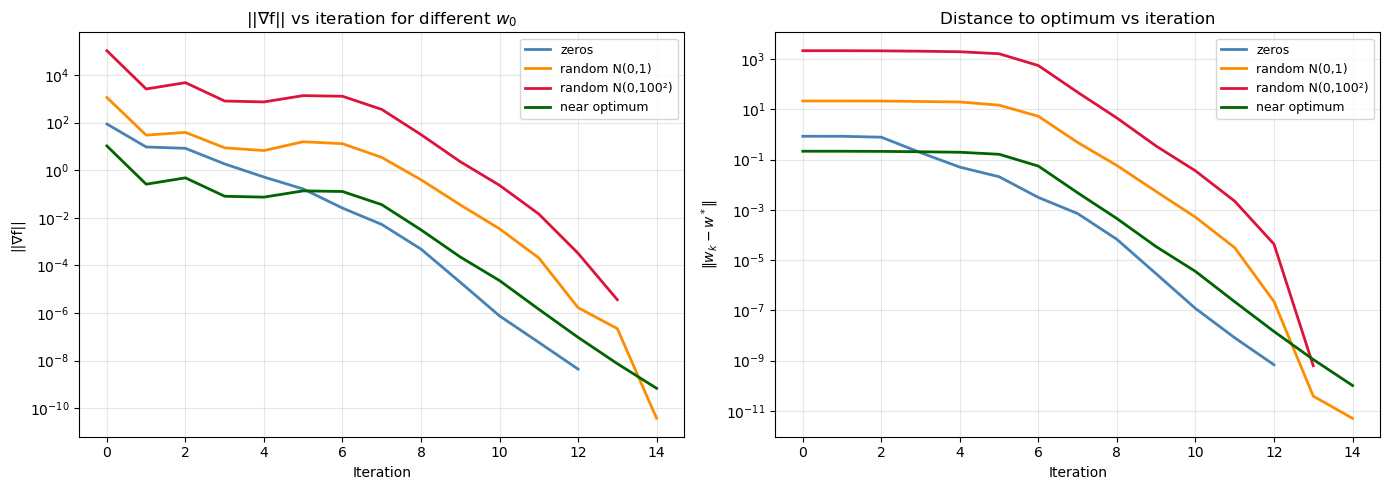

In [18]:
# Initial point sensitivity: same 1x2 structure, using the init strategies present in the grid.
results_init = {}
init_colors = {'zeros': 'steelblue', 'random N(0,1)': 'darkorange',
               'random N(0,100²)': 'crimson', 'near optimum': 'darkgreen'}

for init_name in grid['init_strategy']:
    row = nearest_row({
        'lam': base_lambda,
        'h0_scaling': 'nocedal',
        'm_history': 10,
        'line_search': 'exact',
        'wolfe_c1': 1e-4,
        'wolfe_c2': 0.5,
        'use_restart': False,
        'restart_xi': 0.20,
        'init_strategy': init_name,
    })
    results_init[init_name] = row['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, h in results_init.items():
    ax.semilogy(h['grad_norm'], lw=2, color=init_colors[label], label=label)
ax.set(xlabel='Iteration', ylabel='||∇f||',
       title='||∇f|| vs iteration for different $w_0$')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

ax = axes[1]
for label, h in results_init.items():
    ax.semilogy(h['dist_to_opt'], lw=2, color=init_colors[label], label=label)
ax.set(xlabel='Iteration', ylabel=r'$\|w_k - w^*\|$',
       title='Distance to optimum vs iteration')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

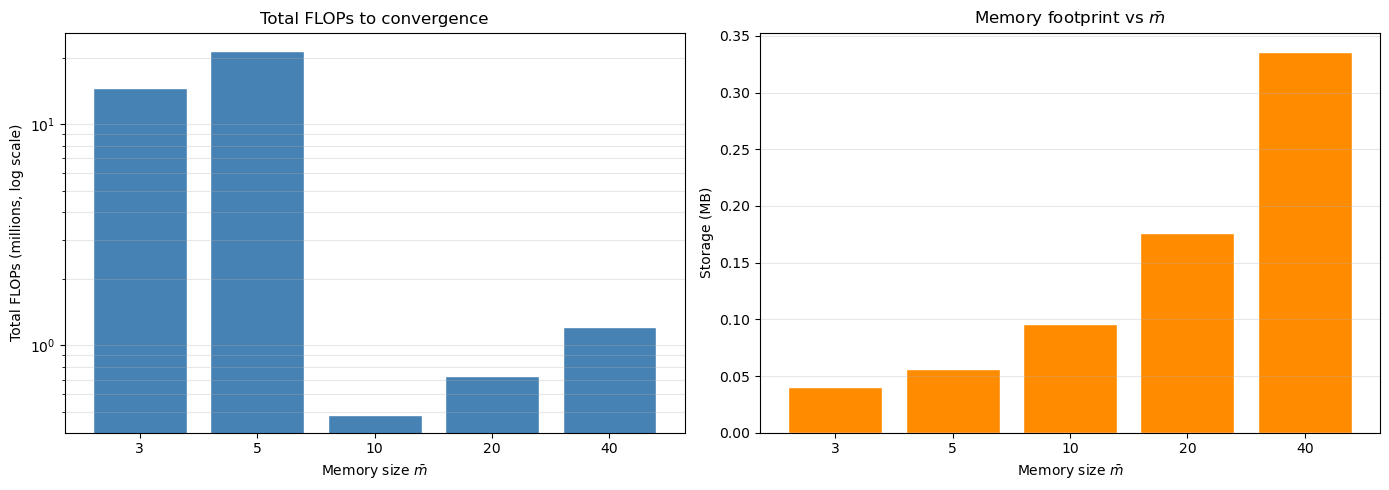

In [19]:
# Cost/storage structures reused from the experiments notebook.
flop_comparison = []
for mh in [3, 5, 10, 20, 40]:
    row = nearest_row({
        'lam': base_lambda,
        'h0_scaling': 'nocedal',
        'm_history': mh,
        'line_search': 'exact',
        'wolfe_c1': 1e-4,
        'wolfe_c2': 0.5,
        'use_restart': False,
        'restart_xi': 0.20,
        'init_strategy': 'zeros',
    })
    n_iter_actual = int(row['n_iter'])
    c = theoretical_cost(m, n, mh, n_iter_actual)
    flop_comparison.append((mh, n_iter_actual, c))

mh_vals = [fc[0] for fc in flop_comparison]
tot_flops = [fc[2]['total_flops'] for fc in flop_comparison]
stor_mb = [fc[2]['storage_MB'] for fc in flop_comparison]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
positions = np.arange(len(mh_vals))
labels = [str(mh) for mh in mh_vals]

axes[0].bar(positions, [f/1e6 for f in tot_flops],
            color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set(xlabel='Memory size $\\bar{m}$',
            ylabel='Total FLOPs (millions, log scale)',
            title='Total FLOPs to convergence')
axes[0].set_xticks(positions); axes[0].set_xticklabels(labels)
axes[0].grid(axis='y', alpha=0.3, which='both')

axes[1].bar(positions, stor_mb,
            color='darkorange', edgecolor='white')
axes[1].set(xlabel='Memory size $\\bar{m}$',
            ylabel='Storage (MB)',
            title='Memory footprint vs $\\bar{m}$')
axes[1].set_xticks(positions); axes[1].set_xticklabels(labels)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

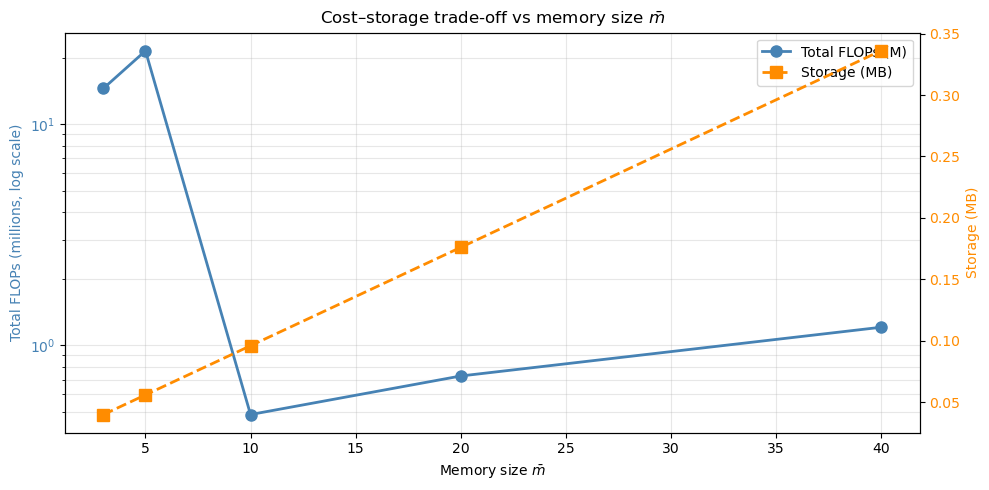

In [20]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = 'steelblue'
color2 = 'darkorange'

ax1.plot(mh_vals, [f/1e6 for f in tot_flops],
         'o-', lw=2, color=color1, ms=8, label='Total FLOPs (M)')
ax1.set_yscale('log')
ax1.set_xlabel('Memory size $\\bar{m}$')
ax1.set_ylabel('Total FLOPs (millions, log scale)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(mh_vals, stor_mb,
         's--', lw=2, color=color2, ms=8, label='Storage (MB)')
ax2.set_ylabel('Storage (MB)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Cost–storage trade-off vs memory size $\\bar{m}$')
ax1.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()